# Predict Future Stock Prices (Short-Term)

## Objective
Use historical stock market data to predict the **next day's closing price** for one selected stock.


## What this notebook does
- Loads historical stock data using **yfinance**
- Performs exploratory analysis
- Splits data into train / validation / test
- Trains and compares Linear Regression and Random Forest models
- Evaluates on unseen test data
- Saves the final model artifact
- Produces actual vs predicted plots

In [120]:
import os
import glob
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

print("Libraries imported successfully.")

Libraries imported successfully.


## Configuration
AAPL is used by default because it is liquid, well-known, and typically has enough data for stable short-term modeling.

In [121]:
TARGET_TICKER = "AAPL"
RANDOM_STATE = 42
TEST_SIZE = 0.2
VAL_SIZE = 0.15

print(f"Selected ticker: {TARGET_TICKER}")
print(f"Split ratios -> train: {1-TEST_SIZE-VAL_SIZE:.2f}, val: {VAL_SIZE:.2f}, test: {TEST_SIZE:.2f}")

Selected ticker: AAPL
Split ratios -> train: 0.65, val: 0.15, test: 0.20


## Data Loading Strategy
We try `yfinance` first because the task explicitly asks for data retrieval through Yahoo Finance APIs.  
If that fails, we search the Kaggle input directory and load the CSV fallback.

In [122]:
import ast

def _flatten_column_name(c):
    """Flatten yfinance / pandas MultiIndex-like columns into plain strings."""
    if isinstance(c, tuple):
        c = c[0] if len(c) > 0 else c

    s = str(c).strip().replace("\ufeff", "")

    # Handle stringified tuples like "('Close', 'AAPL')"
    if s.startswith("(") and s.endswith(")"):
        try:
            parsed = ast.literal_eval(s)
            if isinstance(parsed, tuple) and len(parsed) > 0:
                s = str(parsed[0]).strip()
        except Exception:
            pass

    return s


def fetch_from_yfinance(ticker: str, period: str = "5y"):
    # Fetch historical stock data using yfinance
    try:
        import yfinance as yf
    except Exception as exc:
        print(f"yfinance import failed: {exc}")
        return None

    try:
        data = yf.download(
            ticker,
            period=period,
            interval="1d",
            auto_adjust=False,
            progress=False
        )
        if data is None or data.empty:
            return None

        data = data.reset_index()
        data["Ticker"] = ticker
        return data
    except Exception as exc:
        print(f"yfinance download failed: {exc}")
        return None


def standardize_stock_columns(df: pd.DataFrame) -> pd.DataFrame:
    # Standardize common stock-data column names
    df = df.copy()

    # First flatten any MultiIndex / tuple-like columns
    df.columns = [_flatten_column_name(c) for c in df.columns]

    rename_map = {}
    for c in df.columns:
        lc = str(c).lower().strip()
        if lc == "date":
            rename_map[c] = "Date"
        elif lc == "open":
            rename_map[c] = "Open"
        elif lc == "high":
            rename_map[c] = "High"
        elif lc == "low":
            rename_map[c] = "Low"
        elif lc == "close":
            rename_map[c] = "Close"
        elif lc in {"adj close", "adj_close"}:
            rename_map[c] = "Adj Close"
        elif lc == "volume":
            rename_map[c] = "Volume"
        elif lc == "dividends":
            rename_map[c] = "Dividends"
        elif lc in {"stock splits", "stock_splits", "stocksplits"}:
            rename_map[c] = "Stock Splits"
        elif lc in {"company", "symbol", "ticker"}:
            rename_map[c] = "Ticker"

    df = df.rename(columns=rename_map)

    # Drop duplicate columns after flattening/renaming
    df = df.loc[:, ~df.columns.duplicated()].copy()

    if "Date" in df.columns:
        df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

    numeric_candidates = [
        "Open", "High", "Low", "Close", "Adj Close",
        "Volume", "Dividends", "Stock Splits"
    ]
    for col in numeric_candidates:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    return df


def load_data(target_ticker: str):
    # Prefer yfinance. If unavailable, fall back to Kaggle CSV data.
    yf_df = fetch_from_yfinance(target_ticker)
    if yf_df is not None and not yf_df.empty:
        yf_df = standardize_stock_columns(yf_df)
        return yf_df, "yfinance"

    print("Falling back to Kaggle CSV dataset...")
    csv_candidates = glob.glob("/kaggle/input/**/*.csv", recursive=True)
    if not csv_candidates:
        raise FileNotFoundError("No CSV file found under /kaggle/input and yfinance fetch also failed.")

    preferred = [p for p in csv_candidates if p.endswith("stock_details_5_years.csv")]
    csv_path = preferred[0] if preferred else csv_candidates[0]
    print(f"Using CSV file: {csv_path}")

    df = pd.read_csv(csv_path)
    df = standardize_stock_columns(df)

    ticker_col_candidates = [c for c in ["Ticker", "Company", "Symbol"] if c in df.columns]
    if not ticker_col_candidates:
        raise KeyError("No ticker/company column found in the Kaggle fallback CSV.")

    ticker_col = ticker_col_candidates[0]
    print(f"Detected ticker column: {ticker_col}")

    if target_ticker in df[ticker_col].astype(str).unique():
        df = df[df[ticker_col].astype(str) == target_ticker].copy()
    else:
        top_ticker = df[ticker_col].astype(str).value_counts().index[0]
        print(f"Ticker {target_ticker} not found. Falling back to {top_ticker}.")
        df = df[df[ticker_col].astype(str) == top_ticker].copy()

    return df, "kaggle_csv"


df, DATA_SOURCE = load_data(TARGET_TICKER)

print(f"Data source used: {DATA_SOURCE}")
print("Loaded shape:", df.shape)
display(df.head())

Data source used: yfinance
Loaded shape: (1256, 8)


,Date,Adj Close,Close,High,Low,Open,Volume,Ticker
0,2021-05-13,121.814751,124.970001,126.150002,124.260002,124.580002,105861300,AAPL
1,2021-05-14,124.232140,127.449997,127.889999,125.849998,126.250000,81918000,AAPL
2,2021-05-17,123.081932,126.269997,126.930000,125.169998,126.820000,74244600,AAPL
3,2021-05-18,121.697800,124.849998,126.989998,124.779999,126.559998,63342900,AAPL
4,2021-05-19,121.541817,124.690002,124.919998,122.860001,123.160004,92612000,AAPL


## Initial Inspection
We check the dataset shape, column names, and sample rows.

In [123]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

print("\nLast 5 rows:")
display(df.tail())

Shape: (1256, 8)

Columns:
['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume', 'Ticker']

First 5 rows:


,Date,Adj Close,Close,High,Low,Open,Volume,Ticker
0,2021-05-13,121.814751,124.970001,126.150002,124.260002,124.580002,105861300,AAPL
1,2021-05-14,124.232140,127.449997,127.889999,125.849998,126.250000,81918000,AAPL
2,2021-05-17,123.081932,126.269997,126.930000,125.169998,126.820000,74244600,AAPL
3,2021-05-18,121.697800,124.849998,126.989998,124.779999,126.559998,63342900,AAPL
4,2021-05-19,121.541817,124.690002,124.919998,122.860001,123.160004,92612000,AAPL



Last 5 rows:


,Date,Adj Close,Close,High,Low,Open,Volume,Ticker
1251,2026-05-07,287.175415,287.440002,292.130005,285.779999,289.269989,45224300,AAPL
1252,2026-05-08,293.050018,293.320007,294.760010,290.000000,290.010010,52692800,AAPL
1253,2026-05-11,292.679993,292.679993,293.880005,290.230011,291.980011,42247300,AAPL
1254,2026-05-12,294.799988,294.799988,295.269989,292.559998,292.559998,45689300,AAPL
1255,2026-05-13,298.923004,298.923004,300.920013,293.559998,293.630005,33508344,AAPL


In [124]:
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1256 entries, 0 to 1255
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       1256 non-null   datetime64[ns]
 1   Adj Close  1256 non-null   float64       
 2   Close      1256 non-null   float64       
 3   High       1256 non-null   float64       
 4   Low        1256 non-null   float64       
 5   Open       1256 non-null   float64       
 6   Volume     1256 non-null   int64         
 7   Ticker     1256 non-null   object        
dtypes: datetime64[ns](1), float64(5), int64(1), object(1)
memory usage: 78.6+ KB


In [125]:
print("Descriptive Statistics:")
display(df.describe(include="all"))

Descriptive Statistics:


,Date,Adj Close,Close,High,Low,Open,Volume,Ticker
count,1256,1256.000000,1256.000000,1256.000000,1256.000000,1256.000000,1.256000e+03,1256
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AAPL
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1256
mean,2023-11-10 23:47:23.312101632,189.174473,191.253219,193.125669,189.191919,191.048503,6.569584e+07,NaN
min,2021-05-13 00:00:00,120.420868,123.540001,124.849998,122.860001,123.160004,1.791060e+07,NaN
25%,2022-08-10 18:00:00,152.600731,155.325001,157.219997,153.400002,155.052505,4.637302e+07,NaN
50%,2023-11-08 12:00:00,179.053543,181.169998,182.885002,179.184998,181.270004,5.874865e+07,NaN
75%,2025-02-11 06:00:00,224.015694,225.257496,226.962502,223.250000,224.944996,7.793110e+07,NaN
max,2026-05-13 00:00:00,298.923004,298.923004,300.920013,293.559998,293.630005,3.186799e+08,NaN


## Basic Cleaning
We remove duplicates, sort by date, and keep only valid records for modeling.

In [126]:
# ============================================
# DATA VALIDATION AND CLEANING
# ============================================

print("Columns after loading/standardization:")
print(df.columns.tolist())

required_columns = ["Date", "Open", "High", "Low", "Close", "Volume"]
missing_columns = [col for col in required_columns if col not in df.columns]

if missing_columns:
    raise KeyError(f"Missing required columns: {missing_columns}")

# Ensure Date is datetime
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# Remove invalid dates and duplicates
before_rows = len(df)
df = df.dropna(subset=["Date"]).drop_duplicates().copy()
after_rows = len(df)

# Sort chronologically
df = df.sort_values("Date").reset_index(drop=True)

print(f"Removed {before_rows - after_rows} duplicate/invalid rows.")
print("After cleaning shape:", df.shape)
print("Date range:", df["Date"].min(), "to", df["Date"].max())

display(df.head())

Columns after loading/standardization:
['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume', 'Ticker']
Removed 0 duplicate/invalid rows.
After cleaning shape: (1256, 8)
Date range: 2021-05-13 00:00:00 to 2026-05-13 00:00:00


,Date,Adj Close,Close,High,Low,Open,Volume,Ticker
0,2021-05-13,121.814751,124.970001,126.150002,124.260002,124.580002,105861300,AAPL
1,2021-05-14,124.232140,127.449997,127.889999,125.849998,126.250000,81918000,AAPL
2,2021-05-17,123.081932,126.269997,126.930000,125.169998,126.820000,74244600,AAPL
3,2021-05-18,121.697800,124.849998,126.989998,124.779999,126.559998,63342900,AAPL
4,2021-05-19,121.541817,124.690002,124.919998,122.860001,123.160004,92612000,AAPL


In [127]:
missing = df.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]

if len(missing) == 0:
    print("No missing values detected in the cleaned data.")
else:
    display(missing)

No missing values detected in the cleaned data.


## Exploratory Data Analysis
We inspect trends and distribution before training the model.

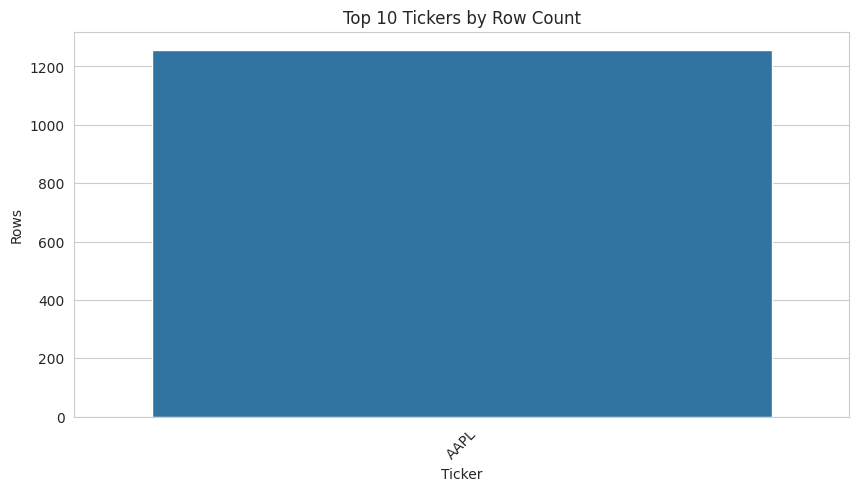

In [128]:
ticker_col = next((c for c in ["Ticker", "Company", "Symbol"] if c in df.columns), None)

if ticker_col is not None:
    plt.figure(figsize=(10, 5))
    top_counts = df[ticker_col].astype(str).value_counts().head(10)
    sns.barplot(x=top_counts.index, y=top_counts.values)
    plt.title("Top 10 Tickers by Row Count")
    plt.xlabel("Ticker")
    plt.ylabel("Rows")
    plt.xticks(rotation=45)
    plt.show()

In [129]:
if "Date" not in df.columns:
    raise KeyError(f"Date column missing after cleaning. Current columns: {df.columns.tolist()}")

if ticker_col is not None and df[ticker_col].astype(str).nunique() > 1:
    if TARGET_TICKER in df[ticker_col].astype(str).unique():
        stock_df = df[df[ticker_col].astype(str) == TARGET_TICKER].copy()
    else:
        stock_df = df[df[ticker_col].astype(str) == df[ticker_col].astype(str).value_counts().index[0]].copy()
else:
    stock_df = df.copy()

stock_df = stock_df.sort_values("Date").reset_index(drop=True)
print("Selected stock shape:", stock_df.shape)
display(stock_df.head())

Selected stock shape: (1256, 8)


,Date,Adj Close,Close,High,Low,Open,Volume,Ticker
0,2021-05-13,121.814751,124.970001,126.150002,124.260002,124.580002,105861300,AAPL
1,2021-05-14,124.232140,127.449997,127.889999,125.849998,126.250000,81918000,AAPL
2,2021-05-17,123.081932,126.269997,126.930000,125.169998,126.820000,74244600,AAPL
3,2021-05-18,121.697800,124.849998,126.989998,124.779999,126.559998,63342900,AAPL
4,2021-05-19,121.541817,124.690002,124.919998,122.860001,123.160004,92612000,AAPL


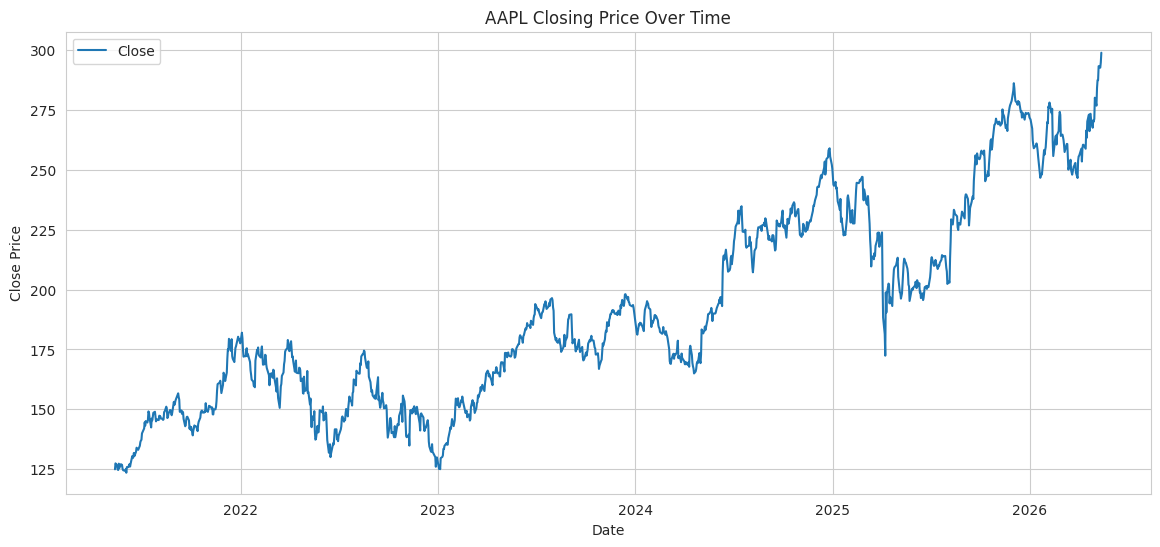

In [130]:
if {"Date", "Close"}.issubset(stock_df.columns):
    plt.figure(figsize=(14, 6))
    plt.plot(stock_df["Date"], stock_df["Close"], label="Close")
    plt.title(f"{TARGET_TICKER} Closing Price Over Time")
    plt.xlabel("Date")
    plt.ylabel("Close Price")
    plt.legend()
    plt.show()
else:
    print("Cannot plot closing price: required columns are missing.")

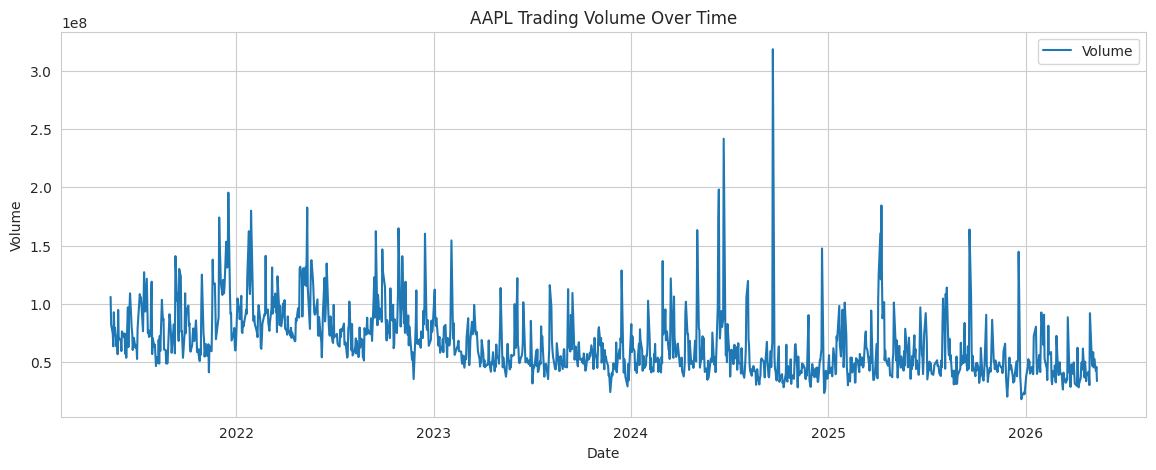

In [131]:
if {"Date", "Volume"}.issubset(stock_df.columns):
    plt.figure(figsize=(14, 5))
    plt.plot(stock_df["Date"], stock_df["Volume"], label="Volume")
    plt.title(f"{TARGET_TICKER} Trading Volume Over Time")
    plt.xlabel("Date")
    plt.ylabel("Volume")
    plt.legend()
    plt.show()
else:
    print("Cannot plot volume: required columns are missing.")

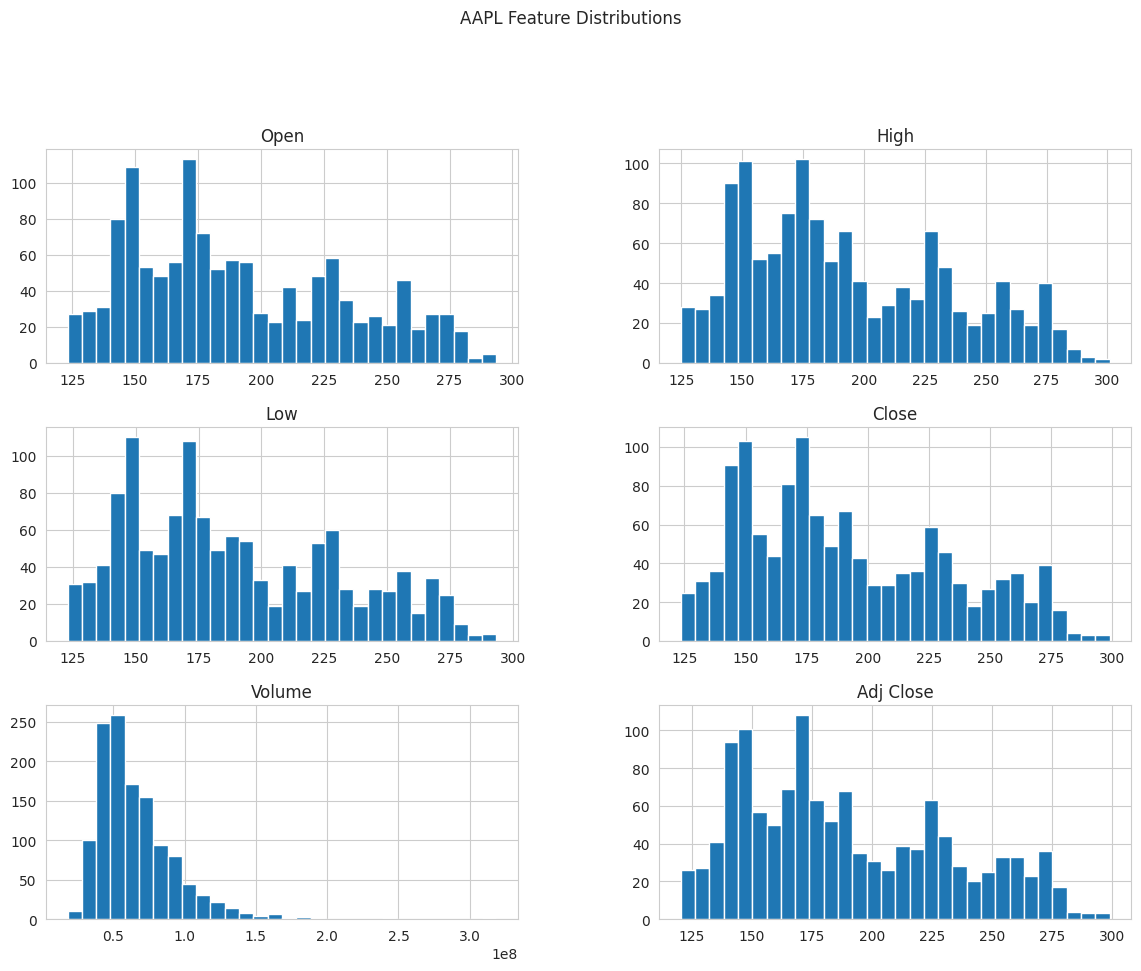

In [132]:
numeric_hist_cols = [
    c for c in ["Open", "High", "Low", "Close", "Volume", "Adj Close", "Dividends", "Stock Splits"]
    if c in stock_df.columns and pd.api.types.is_numeric_dtype(stock_df[c])
]

if numeric_hist_cols:
    stock_df[numeric_hist_cols].hist(figsize=(14, 10), bins=30)
    plt.suptitle(f"{TARGET_TICKER} Feature Distributions", y=1.02)
    plt.show()
else:
    print("No numeric columns available for histogram plotting.")

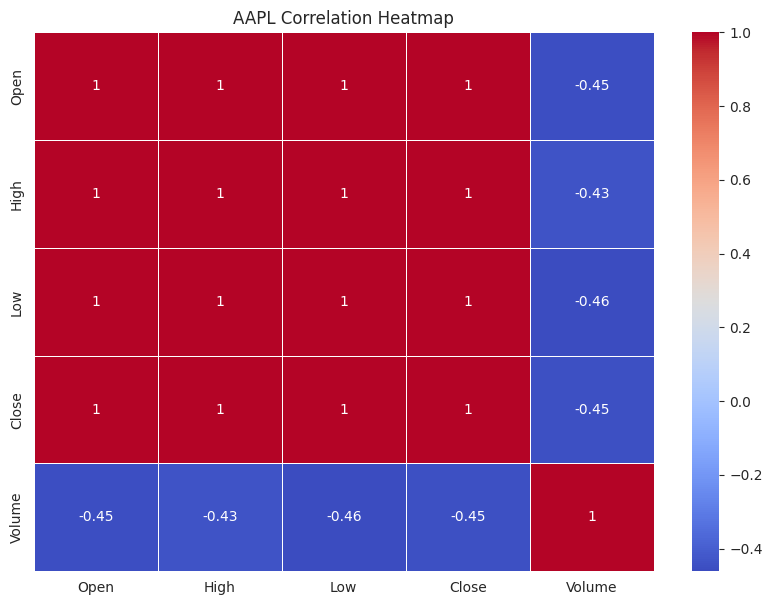

In [133]:
corr_cols = [
    c for c in ["Open", "High", "Low", "Close", "Volume", "Dividends", "Stock Splits"]
    if c in stock_df.columns and pd.api.types.is_numeric_dtype(stock_df[c])
]

if len(corr_cols) >= 2:
    plt.figure(figsize=(10, 7))
    sns.heatmap(stock_df[corr_cols].corr(numeric_only=True), annot=True, cmap="coolwarm", linewidths=0.5)
    plt.title(f"{TARGET_TICKER} Correlation Heatmap")
    plt.show()
else:
    print("Not enough numeric columns to compute correlation heatmap.")

## Feature Engineering
We build **time-safe** features using only information available on or before the current day.

### Target
`Target_Next_Close` = next day's closing price

### Features
- Open
- High
- Low
- Volume
- Previous close
- Daily range
- Daily return
- Rolling means / volatility

This keeps the model practical and reduces the risk of look-ahead leakage.

In [134]:
required_for_features = {"Date", "Close", "High", "Low", "Open", "Volume"}
if not required_for_features.issubset(stock_df.columns):
    raise KeyError(f"Required columns missing for feature engineering: {sorted(required_for_features - set(stock_df.columns))}")

stock_df = stock_df.copy()

stock_df["Prev_Close"] = stock_df["Close"].shift(1)
stock_df["Daily_Range"] = stock_df["High"] - stock_df["Low"]
stock_df["Daily_Return"] = stock_df["Close"].pct_change()
stock_df["Rolling_Mean_5"] = stock_df["Close"].shift(1).rolling(5).mean()
stock_df["Rolling_Mean_10"] = stock_df["Close"].shift(1).rolling(10).mean()
stock_df["Rolling_Std_5"] = stock_df["Close"].shift(1).rolling(5).std()
stock_df["Target_Next_Close"] = stock_df["Close"].shift(-1)

display(stock_df.head(8))

,Date,Adj Close,Close,High,Low,Open,Volume,Ticker,Prev_Close,Daily_Range,Daily_Return,Rolling_Mean_5,Rolling_Mean_10,Rolling_Std_5,Target_Next_Close
0,2021-05-13,121.814751,124.970001,126.150002,124.260002,124.580002,105861300,AAPL,NaN,1.889999,NaN,NaN,NaN,NaN,127.449997
1,2021-05-14,124.232140,127.449997,127.889999,125.849998,126.250000,81918000,AAPL,124.970001,2.040001,0.019845,NaN,NaN,NaN,126.269997
2,2021-05-17,123.081932,126.269997,126.930000,125.169998,126.820000,74244600,AAPL,127.449997,1.760002,-0.009259,NaN,NaN,NaN,124.849998
3,2021-05-18,121.697800,124.849998,126.989998,124.779999,126.559998,63342900,AAPL,126.269997,2.209999,-0.011246,NaN,NaN,NaN,124.690002
4,2021-05-19,121.541817,124.690002,124.919998,122.860001,123.160004,92612000,AAPL,124.849998,2.059998,-0.001282,NaN,NaN,NaN,127.309998
5,2021-05-20,124.095680,127.309998,127.720001,125.099998,125.230003,76857100,AAPL,124.690002,2.620003,0.021012,125.645999,NaN,1.188308,125.430000
6,2021-05-21,122.263130,125.430000,128.000000,125.209999,127.820000,79295400,AAPL,127.309998,2.790001,-0.014767,126.113998,NaN,1.310067,127.099998
7,2021-05-24,123.890968,127.099998,127.940002,125.940002,126.010002,63092900,AAPL,125.430000,2.000000,0.013314,125.709999,NaN,1.087656,126.900002


In [135]:
feature_cols = [
    c for c in [
        "Open", "High", "Low", "Volume",
        "Prev_Close", "Daily_Range", "Daily_Return",
        "Rolling_Mean_5", "Rolling_Mean_10", "Rolling_Std_5"
    ]
    if c in stock_df.columns
]

model_df = stock_df[["Date"] + feature_cols + ["Target_Next_Close"]].dropna().copy()

if model_df.empty:
    raise ValueError("Modeling dataframe is empty after feature engineering. Check data availability and feature creation.")

print("Modeling dataframe shape:", model_df.shape)
display(model_df.head())

Modeling dataframe shape: (1245, 12)


,Date,Open,High,Low,Volume,Prev_Close,Daily_Range,Daily_Return,Rolling_Mean_5,Rolling_Mean_10,Rolling_Std_5,Target_Next_Close
10,2021-05-27,126.440002,127.639999,125.080002,94625600,126.849998,2.559998,-0.012377,126.717999,126.181999,0.742609,124.610001
11,2021-05-28,125.570000,125.800003,124.550003,71311100,125.279999,1.250000,-0.005348,126.312000,126.212999,0.880210,124.279999
12,2021-06-01,125.080002,125.349998,123.940002,67637100,124.610001,1.409996,-0.002648,126.148000,125.928999,1.127328,125.059998
13,2021-06-02,124.279999,125.239998,124.050003,59278900,124.279999,1.189995,0.006276,125.584000,125.730000,1.232490,123.540001
14,2021-06-03,124.680000,124.849998,123.129997,76229200,125.059998,1.720001,-0.012154,125.215999,125.750999,0.992688,125.889999


## Chronological Train / Validation / Test Split
Time-series data must **not** be shuffled randomly.

We use:
- **Train**: first 70%
- **Validation**: next 15%
- **Test**: last 20%


- honest validation for tuning,
- a final unseen test set,
- better generalization,
- and a more realistic evaluation.

In [136]:
n = len(model_df)
train_end = int(n * (1 - TEST_SIZE - VAL_SIZE))
val_end = int(n * (1 - TEST_SIZE))

train_df = model_df.iloc[:train_end].copy()
val_df = model_df.iloc[train_end:val_end].copy()
test_df = model_df.iloc[val_end:].copy()

X_train = train_df[feature_cols]
y_train = train_df["Target_Next_Close"]

X_val = val_df[feature_cols]
y_val = val_df["Target_Next_Close"]

X_test = test_df[feature_cols]
y_test = test_df["Target_Next_Close"]

dates_test = test_df["Date"]

print("Train range:", train_df["Date"].min(), "->", train_df["Date"].max(), "| rows:", len(train_df))
print("Val range:  ", val_df["Date"].min(), "->", val_df["Date"].max(), "| rows:", len(val_df))
print("Test range: ", test_df["Date"].min(), "->", test_df["Date"].max(), "| rows:", len(test_df))

Train range: 2021-05-27 00:00:00 -> 2024-08-14 00:00:00 | rows: 809
Val range:   2024-08-15 00:00:00 -> 2025-05-14 00:00:00 | rows: 187
Test range:  2025-05-15 00:00:00 -> 2026-05-12 00:00:00 | rows: 249


## Baseline Model
A simple naive baseline helps us understand whether the machine learning model is actually doing better than a trivial guess.

For next-day close prediction, a strong baseline is:
- **predict next close = today's close**

In [137]:
# ============================================
# NAIVE BASELINE MODEL
# ============================================

# Use the most recent close-related feature as a naive prediction baseline

baseline_candidates = [
    "Close",
    "Adj Close",
    "Prev_Close",
    "Close_Lag_1"
]

baseline_col = next(
    (c for c in baseline_candidates if c in val_df.columns and c in test_df.columns),
    None
)

if baseline_col is None:
    print("Available Validation Columns:")
    print(val_df.columns.tolist())
    raise KeyError("No suitable baseline column found.")

baseline_val_pred = val_df[baseline_col].to_numpy()
baseline_test_pred = test_df[baseline_col].to_numpy()

def regression_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mse),
        "R2": r2_score(y_true, y_pred)
    }

baseline_results = pd.DataFrame([
    {
        "Split": "Validation",
        "Model": f"Naive {baseline_col} Baseline",
        **regression_metrics(y_val, baseline_val_pred)
    },
    {
        "Split": "Test",
        "Model": f"Naive {baseline_col} Baseline",
        **regression_metrics(y_test, baseline_test_pred)
    },
])

display(baseline_results)

,Split,Model,MAE,RMSE,R2
0,Validation,Naive Prev_Close Baseline,4.456149,6.484334,0.817554
1,Test,Naive Prev_Close Baseline,3.837683,5.171103,0.962940


## Model Training
We train two candidates:
- **Linear Regression** — strong, interpretable baseline
- **Random Forest Regressor** — nonlinear model that can capture more complex interactions

We evaluate on the **validation set** first so we can select the best configuration without touching the test set.

In [138]:
def evaluate_model(model, X_tr, y_tr, X_eval, y_eval):
    pred_tr = model.predict(X_tr)
    pred_eval = model.predict(X_eval)

    train_mse = mean_squared_error(y_tr, pred_tr)
    eval_mse = mean_squared_error(y_eval, pred_eval)

    out = {
        "train_mae": mean_absolute_error(y_tr, pred_tr),
        "train_rmse": np.sqrt(train_mse),
        "train_r2": r2_score(y_tr, pred_tr),
        "eval_mae": mean_absolute_error(y_eval, pred_eval),
        "eval_rmse": np.sqrt(eval_mse),
        "eval_r2": r2_score(y_eval, pred_eval),
        "train_pred": pred_tr,
        "eval_pred": pred_eval
    }
    return out

# Candidate 1: Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_val = evaluate_model(lr_model, X_train, y_train, X_val, y_val)

# Candidate 2: Random Forest grid on validation set
rf_grid = [
    {"n_estimators": 200, "max_depth": 5,  "min_samples_leaf": 3, "max_features": "sqrt"},
    {"n_estimators": 300, "max_depth": 8,  "min_samples_leaf": 2, "max_features": "sqrt"},
    {"n_estimators": 500, "max_depth": 12, "min_samples_leaf": 2, "max_features": "sqrt"},
    {"n_estimators": 400, "max_depth": None, "min_samples_leaf": 4, "max_features": "sqrt"},
]

rf_trials = []
best_rf_model = None
best_rf_val_rmse = float("inf")
best_rf_params = None
best_rf_metrics = None

for params in rf_grid:
    rf = RandomForestRegressor(
        random_state=RANDOM_STATE,
        n_jobs=-1,
        **params
    )
    rf.fit(X_train, y_train)
    scores = evaluate_model(rf, X_train, y_train, X_val, y_val)
    rf_trials.append({
        **params,
        "train_rmse": scores["train_rmse"],
        "eval_rmse": scores["eval_rmse"],
        "train_r2": scores["train_r2"],
        "eval_r2": scores["eval_r2"]
    })
    if scores["eval_rmse"] < best_rf_val_rmse:
        best_rf_val_rmse = scores["eval_rmse"]
        best_rf_model = rf
        best_rf_params = params
        best_rf_metrics = scores

rf_trials_df = pd.DataFrame(rf_trials).sort_values("eval_rmse")
display(rf_trials_df)

summary_rows = [
    {
        "Model": "Linear Regression",
        "Train_RMSE": lr_val["train_rmse"],
        "Val_RMSE": lr_val["eval_rmse"],
        "Train_R2": lr_val["train_r2"],
        "Val_R2": lr_val["eval_r2"],
    },
    {
        "Model": "Random Forest (best validation)",
        "Train_RMSE": best_rf_metrics["train_rmse"],
        "Val_RMSE": best_rf_metrics["eval_rmse"],
        "Train_R2": best_rf_metrics["train_r2"],
        "Val_R2": best_rf_metrics["eval_r2"],
    },
]

summary_df = pd.DataFrame(summary_rows).sort_values("Val_RMSE")
display(summary_df)

,n_estimators,max_depth,min_samples_leaf,max_features,train_rmse,eval_rmse,train_r2,eval_r2
1,300,8.0,2,sqrt,1.842778,9.959135,0.993010,0.569625
2,500,12.0,2,sqrt,1.531685,10.002123,0.995171,0.565902
3,400,NaN,4,sqrt,2.058344,10.116170,0.991279,0.555946
0,200,5.0,3,sqrt,2.656137,10.167378,0.985478,0.551439


,Model,Train_RMSE,Val_RMSE,Train_R2,Val_R2
0,Linear Regression,2.790510,4.642104,0.983971,0.906495
1,Random Forest (best validation),1.842778,9.959135,0.993010,0.569625


## Choose the Best Model
We pick the model with the best validation performance, then retrain it using **train + validation** data before final testing.

This is the correct way to:
- tune on validation,
- avoid test leakage,
- and maximize the data available for the final model.

In [139]:
best_model_name = summary_df.iloc[0]["Model"]
print("Best model based on validation:", best_model_name)

X_train_val = pd.concat([X_train, X_val], axis=0)
y_train_val = pd.concat([y_train, y_val], axis=0)

if best_model_name == "Linear Regression":
    final_model = LinearRegression()
    final_model.fit(X_train_val, y_train_val)
    chosen_params = {"model": "Linear Regression"}
else:
    final_model = RandomForestRegressor(
        random_state=RANDOM_STATE,
        n_jobs=-1,
        **best_rf_params
    )
    final_model.fit(X_train_val, y_train_val)
    chosen_params = best_rf_params

chosen_params

Best model based on validation: Linear Regression


{'model': 'Linear Regression'}

## Final Test Evaluation
The test set is untouched during model selection.  
This is the honest estimate of generalization performance.

In [140]:
test_pred = final_model.predict(X_test)

test_metrics = {
    "Model": best_model_name,
    "MAE": mean_absolute_error(y_test, test_pred),
    "RMSE": np.sqrt(mean_squared_error(y_test, test_pred)),
    "R2": r2_score(y_test, test_pred)
}

display(pd.DataFrame([test_metrics]))

,Model,MAE,RMSE,R2
0,Linear Regression,2.708425,3.758555,0.980422


## Actual vs Predicted Closing Prices
This is the main comparison requested in the task.

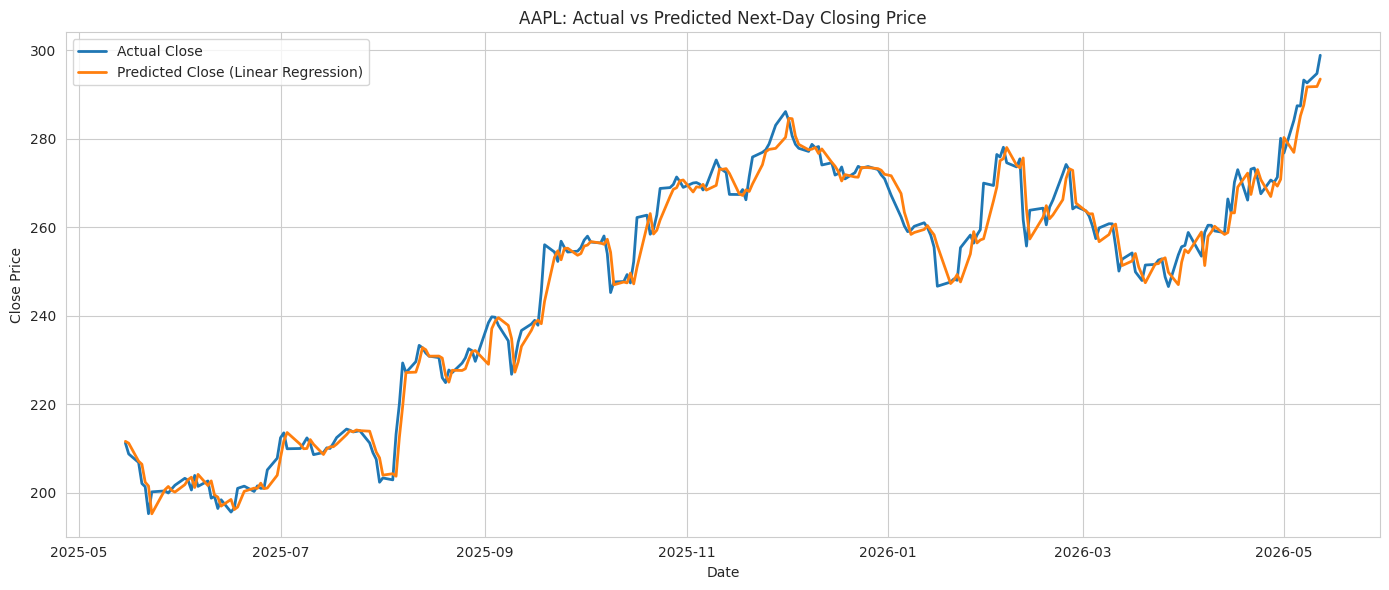

In [141]:
plt.figure(figsize=(14, 6))
plt.plot(dates_test.values, y_test.values, label="Actual Close", linewidth=2)
plt.plot(dates_test.values, test_pred, label=f"Predicted Close ({best_model_name})", linewidth=2)
plt.title(f"{TARGET_TICKER}: Actual vs Predicted Next-Day Closing Price")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()
plt.tight_layout()
plt.show()

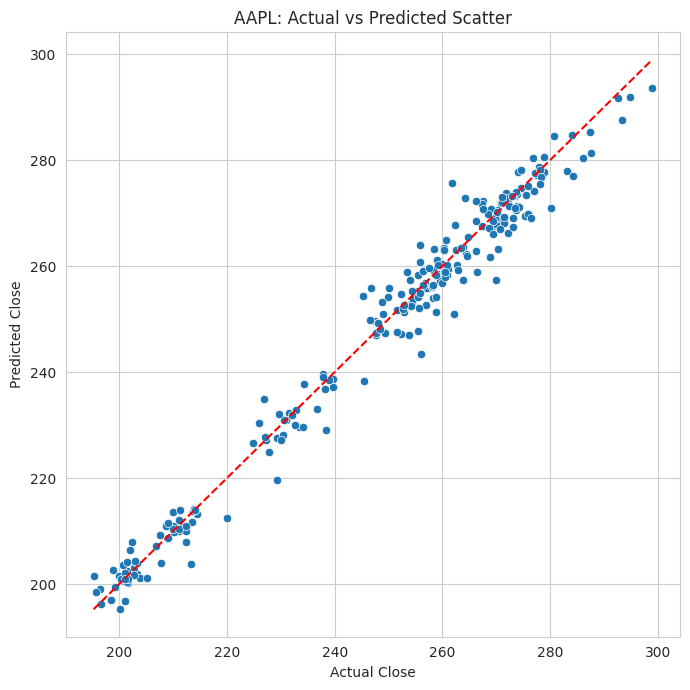

In [142]:
plt.figure(figsize=(7, 7))
sns.scatterplot(x=y_test, y=test_pred)

mn = min(float(y_test.min()), float(test_pred.min()))
mx = max(float(y_test.max()), float(test_pred.max()))
plt.plot([mn, mx], [mn, mx], "r--")

plt.title(f"{TARGET_TICKER}: Actual vs Predicted Scatter")
plt.xlabel("Actual Close")
plt.ylabel("Predicted Close")
plt.tight_layout()
plt.show()

## Save the Final Model Artifact
We save the trained model along with the feature list so it can be reused later.

For scikit-learn models, the saved artifact contains the learned model parameters, which is the practical equivalent of saving model weights.

In [143]:
artifact = {
    "ticker": TARGET_TICKER,
    "data_source": DATA_SOURCE,
    "model_name": best_model_name,
    "model": final_model,
    "feature_cols": feature_cols,
    "notes": "Predict next-day close price"
}

save_path = "/kaggle/working/stock_next_close_model.joblib"
joblib.dump(artifact, save_path)

print(f"Model artifact saved to: {save_path}")

Model artifact saved to: /kaggle/working/stock_next_close_model.joblib


## Quick Reuse Check
We reload the saved artifact and generate a sample prediction to confirm the file works.

In [144]:
loaded_artifact = joblib.load("/kaggle/working/stock_next_close_model.joblib")
loaded_model = loaded_artifact["model"]
loaded_features = loaded_artifact["feature_cols"]

sample_pred = loaded_model.predict(X_test.iloc[:5])
print("Sample predictions from reloaded model:")
print(sample_pred)

Sample predictions from reloaded model:
[211.63060666 211.21393795 207.13386348 206.455148   202.39347964]


## Real-World Forecast for the Most Recent Day
This is the most practical inference step:
- use the latest available market data,
- build the engineered features,
- and predict the **next day's close**.

This is not a test-set score; it is a live-style forecast using the newest observed row.

In [145]:
latest_row = stock_df.sort_values("Date").iloc[-1:].copy()

if len(stock_df) > 1:
    latest_row["Prev_Close"] = stock_df["Close"].iloc[-2]
else:
    latest_row["Prev_Close"] = np.nan

latest_row["Daily_Range"] = latest_row["High"] - latest_row["Low"]
latest_row["Daily_Return"] = stock_df["Close"].pct_change().iloc[-1] if len(stock_df) > 1 else np.nan
latest_row["Rolling_Mean_5"] = stock_df["Close"].iloc[:-1].tail(5).mean() if len(stock_df) > 5 else np.nan
latest_row["Rolling_Mean_10"] = stock_df["Close"].iloc[:-1].tail(10).mean() if len(stock_df) > 10 else np.nan
latest_row["Rolling_Std_5"] = stock_df["Close"].iloc[:-1].tail(5).std() if len(stock_df) > 5 else np.nan

latest_features = latest_row[feature_cols].dropna()

if len(latest_features) == 0:
    print("Not enough history for latest-row forecast after feature engineering.")
else:
    latest_prediction = final_model.predict(latest_features)[0]
    print(f"Latest observed date: {latest_row['Date'].iloc[0].date()}")
    print(f"Predicted next-day close for {TARGET_TICKER}: {latest_prediction:.2f}")

Latest observed date: 2026-05-13
Predicted next-day close for AAPL: 296.99


## Final Insights
- A **chronological split** is essential for stock forecasting because random shuffling would leak future information.
- A validation set allows us to compare models and tune them without touching the test set.
- Random Forest often captures nonlinear behavior better than Linear Regression, but the validation score decides the winner.
- Short-term stock prediction remains hard because prices are noisy and influenced by events outside the feature set.
- Saving the final model artifact makes the notebook reusable and production-friendly.
